# Final_Project_taap_p4

### Developed by:

- António Cruz (140129)
- Cátia Brás (120093)
- Ricardo Kyaseller (95813)

## 1. Introduction and Project Goals

gdgdgdgdgd

## 2. Environment, Reproducibility and Experimental Setup

In [62]:
from importlib import reload
import src.gan.timegan as timegan_module

reload(timegan_module)
from src.gan.timegan import TimeGAN

### 2.1 Libraries Import

In [1]:
import os
import gc
import sys
import json
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import optuna
import psutil

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

I0000 00:00:1774442985.058479  306686 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774442985.142281  306686 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774442986.061219  306686 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/ricarl/taap_p4/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found

### GPU Test

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1774442987.074980  306686 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


### 2.2 Utils Configuration Test

In [3]:
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/home/ricarl/taap_p4


In [4]:
from src.utils.env import set_global_seed, enable_gpu_memory_growth, get_device_info

SEED = 42
set_global_seed(SEED)
enable_gpu_memory_growth()

print(get_device_info())

{'tensorflow_version': '2.21.0', 'num_gpus': 1, 'gpus': ['/physical_device:GPU:0'], 'num_cpus': 1, 'cpus': ['/physical_device:CPU:0']}


## 3. Dataset and Problem Definition

### 3.1 Load Data

In [5]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "src" / "data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists?", DATA_DIR.exists())

PROJECT_ROOT: /home/ricarl/taap_p4
DATA_DIR: /home/ricarl/taap_p4/src/data
DATA_DIR exists? True


In [6]:
DATASET_PATH = DATA_DIR / "jena_climate_2009_2016.csv"

df = pd.read_csv(DATASET_PATH)
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


### 3.2 Initial Dataset Inspection

In [7]:
print("Dataset path:", DATASET_PATH)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nInfo:")
df.info()

Dataset path: /home/ricarl/taap_p4/src/data/jena_climate_2009_2016.csv
Shape: (420551, 15)

Columns:
['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  str    
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/

### 3.2 Data Quality Checks

In [8]:
print("Duplicated rows:", df.duplicated().sum())
print("\nMissing values per column:")
print(df.isna().sum())

Duplicated rows: 327

Missing values per column:
Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64


In [9]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)
print("Duplicated rows after cleanup:", df.duplicated().sum())

Shape after removing duplicates: (420224, 15)
Duplicated rows after cleanup: 0


### 3.3 Datetime Parsing and Temporal Ordering

In [10]:
df["Date Time"] = pd.to_datetime(df["Date Time"], dayfirst=True)
df = df.sort_values("Date Time").reset_index(drop=True)

print(df["Date Time"].min(), "->", df["Date Time"].max())
df[["Date Time"]].head()

2009-01-01 00:10:00 -> 2017-01-01 00:00:00


,Date Time
0,2009-01-01 00:10:00
1,2009-01-01 00:20:00
2,2009-01-01 00:30:00
3,2009-01-01 00:40:00
4,2009-01-01 00:50:00


In [11]:
df["Date Time"].diff().value_counts().head(10)

Date Time
0 days 00:10:00    420218
0 days 00:20:00         2
0 days 00:30:00         1
0 days 16:00:00         1
3 days 02:20:00         1
Name: count, dtype: int64

### 3.4 Hourly Resampling

In [12]:
df_hourly = (
    df.set_index("Date Time")
      .resample("1h")
      .mean()
      .reset_index()
)

print("Original shape:", df.shape)
print("Hourly shape:", df_hourly.shape)
print(df_hourly.head())

Original shape: (420224, 15)
Hourly shape: (70129, 15)
            Date Time    p (mbar)  T (degC)    Tpot (K)  Tdew (degC)  \
0 2009-01-01 00:00:00  996.528000 -8.304000  265.118000    -9.120000   
1 2009-01-01 01:00:00  996.525000 -8.065000  265.361667    -8.861667   
2 2009-01-01 02:00:00  996.745000 -8.763333  264.645000    -9.610000   
3 2009-01-01 03:00:00  996.986667 -8.896667  264.491667    -9.786667   
4 2009-01-01 04:00:00  997.158333 -9.348333  264.026667   -10.345000   

      rh (%)  VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  \
0  93.780000      3.260000      3.058000      0.202000   1.910000   
1  93.933333      3.323333      3.121667      0.201667   1.951667   
2  93.533333      3.145000      2.940000      0.201667   1.836667   
3  93.200000      3.111667      2.898333      0.210000   1.811667   
4  92.383333      3.001667      2.775000      0.231667   1.733333   

   H2OC (mmol/mol)  rho (g/m**3)  wv (m/s)  max. wv (m/s)    wd (deg)  
0         3.068000   1309

### 3.5 Post-Resampling Quality Check

In [13]:
print("Missing values after hourly resampling:")
print(df_hourly.isna().sum())

print("\nDuplicated timestamps after resampling:", df_hourly["Date Time"].duplicated().sum())

print("\nTime step distribution after resampling:")
print(df_hourly["Date Time"].diff().value_counts().head(10))

Missing values after hourly resampling:
Date Time           0
p (mbar)           88
T (degC)           88
Tpot (K)           88
Tdew (degC)        88
rh (%)             88
VPmax (mbar)       88
VPact (mbar)       88
VPdef (mbar)       88
sh (g/kg)          88
H2OC (mmol/mol)    88
rho (g/m**3)       88
wv (m/s)           88
max. wv (m/s)      88
wd (deg)           88
dtype: int64

Duplicated timestamps after resampling: 0

Time step distribution after resampling:
Date Time
0 days 01:00:00    70128
Name: count, dtype: int64


### 3.6 Handling Missing Values After Resampling

In [14]:
df_hourly = df_hourly.dropna().reset_index(drop=True)

print("Shape after dropping NaNs:", df_hourly.shape)
print("\nMissing values after cleanup:")
print(df_hourly.isna().sum().sum())
print("\nTime step distribution after cleanup:")
print(df_hourly["Date Time"].diff().value_counts().head())

Shape after dropping NaNs: (70041, 15)

Missing values after cleanup:
0

Time step distribution after cleanup:
Date Time
0 days 01:00:00    70038
0 days 16:00:00        1
3 days 02:00:00        1
Name: count, dtype: int64


### 3.7 Forecasting Task and Variable Selection

In [15]:
selected_columns = [
    "Date Time",
    "T (degC)",
    "p (mbar)",
    "rh (%)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)"
]

df_model = df_hourly[selected_columns].copy()

print("Selected columns:")
print(df_model.columns.tolist())
print("\nShape:", df_model.shape)
df_model.head()

Selected columns:
['Date Time', 'T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Shape: (70041, 7)


,Date Time,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2,2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
3,2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
4,2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333


## 4. Data Initial Preparation

### 4.1 Target Definition and Base Modeling DataFrame

In [16]:
TARGET_COL = "T (degC)"
TIME_COL = "Date Time"

feature_cols = [col for col in df_model.columns if col not in [TIME_COL]]
input_feature_cols = [col for col in feature_cols]

print("Target:", TARGET_COL)
print("Time column:", TIME_COL)
print("Input features:", input_feature_cols)
print("Number of input features:", len(input_feature_cols))

Target: T (degC)
Time column: Date Time
Input features: ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Number of input features: 6


### 4.2 Base Forecasting Data Overview

In [17]:
print(df_model.head())
print("\nShape:", df_model.shape)
print("\nDate range:", df_model[TIME_COL].min(), "->", df_model[TIME_COL].max())

            Date Time  T (degC)    p (mbar)     rh (%)  wv (m/s)  \
0 2009-01-01 00:00:00 -8.304000  996.528000  93.780000  0.520000   
1 2009-01-01 01:00:00 -8.065000  996.525000  93.933333  0.316667   
2 2009-01-01 02:00:00 -8.763333  996.745000  93.533333  0.248333   
3 2009-01-01 03:00:00 -8.896667  996.986667  93.200000  0.176667   
4 2009-01-01 04:00:00 -9.348333  997.158333  92.383333  0.290000   

   max. wv (m/s)    wd (deg)  
0       1.002000  174.460000  
1       0.711667  172.416667  
2       0.606667  196.816667  
3       0.606667  157.083333  
4       0.670000  150.093333  

Shape: (70041, 7)

Date range: 2009-01-01 00:00:00 -> 2017-01-01 00:00:00


## 5. Feature Engineering

In [18]:
from src.features.engineering import (
    add_time_features,
    add_wind_features,
    get_final_feature_columns,
)
from src.features.windowing import make_windows
from src.models.gru import build_gru_model

### 5.1 Cyclical Time Features

In [19]:
df_feat = add_time_features(df_model, time_col=TIME_COL)

df_feat[[
    TIME_COL, "hour", "dayofyear",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos"
]].head()

,Date Time,hour,dayofyear,hour_sin,hour_cos,doy_sin,doy_cos
0,2009-01-01 00:00:00,0,1,0.000000,1.000000,0.017202,0.999852
1,2009-01-01 01:00:00,1,1,0.258819,0.965926,0.017202,0.999852
2,2009-01-01 02:00:00,2,1,0.500000,0.866025,0.017202,0.999852
3,2009-01-01 03:00:00,3,1,0.707107,0.707107,0.017202,0.999852
4,2009-01-01 04:00:00,4,1,0.866025,0.500000,0.017202,0.999852


### 5.2 Wind-Derived Features

In [20]:
df_feat = add_wind_features(df_feat)

df_feat[[
    TIME_COL, "wv (m/s)", "max. wv (m/s)", "wd (deg)",
    "wd_sin", "wd_cos", "wx", "wy", "wind_gap", "gust_ratio"
]].head()

,Date Time,wv (m/s),max. wv (m/s),wd (deg),wd_sin,wd_cos,wx,wy,wind_gap,gust_ratio
0,2009-01-01 00:00:00,0.520000,1.002000,174.460000,0.096541,-0.995329,-0.517571,0.050201,0.482000,1.926919
1,2009-01-01 01:00:00,0.316667,0.711667,172.416667,0.131968,-0.991254,-0.313897,0.041790,0.395000,2.247361
2,2009-01-01 02:00:00,0.248333,0.606667,196.816667,-0.289310,-0.957235,-0.237713,-0.071845,0.358333,2.442943
3,2009-01-01 03:00:00,0.176667,0.606667,157.083333,0.389392,-0.921072,-0.162723,0.068793,0.430000,3.433943
4,2009-01-01 04:00:00,0.290000,0.670000,150.093333,0.498589,-0.866839,-0.251383,0.144591,0.380000,2.310337


### 5.3 Final Feature Set for Modeling

In [21]:
final_feature_cols = get_final_feature_columns()

print("Number of modeling features:", len(final_feature_cols))
print(final_feature_cols)

Number of modeling features: 16
['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wd_sin', 'wd_cos', 'wx', 'wy', 'wind_gap', 'gust_ratio']


## 6. Split, Scaling and Windowing

### 6.1 Temporal Train/Validation/Test Split

In [22]:
n = len(df_feat)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

df_train = df_feat.iloc[:train_end].copy()
df_val = df_feat.iloc[train_end:val_end].copy()
df_test = df_feat.iloc[val_end:].copy()

print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)

Train shape: (49028, 19)
Validation shape: (10506, 19)
Test shape: (10507, 19)


### 6.2 Feature Scaling

In [23]:
from src.features.scaling import get_scaler

In [24]:
SCALER_NAME = "standard"   # baseline oficial; no EA poderá ser standard/robust/minmax
scaler = get_scaler(SCALER_NAME)

X_train_df = df_train[final_feature_cols].copy()
X_val_df = df_val[final_feature_cols].copy()
X_test_df = df_test[final_feature_cols].copy()

X_train_scaled = scaler.fit_transform(X_train_df)
X_val_scaled = scaler.transform(X_val_df)
X_test_scaled = scaler.transform(X_test_df)

print("Scaler:", SCALER_NAME)
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled val shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaler: standard
Scaled train shape: (49028, 16)
Scaled val shape: (10506, 16)
Scaled test shape: (10507, 16)


### 6.3 Target Index for Forecasting

In [25]:
target_idx = final_feature_cols.index(TARGET_COL)

print("Target column:", TARGET_COL)
print("Target index:", target_idx)

Target column: T (degC)
Target index: 0


### 6.4 Supervised Windowing

In [26]:
from src.features.windowing import make_windows

In [27]:
LOOKBACK = 120
HORIZON = 24

X_train, y_train = make_windows(X_train_scaled, target_idx, LOOKBACK, HORIZON)
X_val, y_val = make_windows(X_val_scaled, target_idx, LOOKBACK, HORIZON)
X_test, y_test = make_windows(X_test_scaled, target_idx, LOOKBACK, HORIZON)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (48885, 120, 16) y_train: (48885, 24)
X_val: (10363, 120, 16) y_val: (10363, 24)
X_test: (10364, 120, 16) y_test: (10364, 24)


### 6.5 Windowed Data Sanity Check

In [28]:
print("Input shape:", X_train.shape[1:])
print("Forecast horizon:", y_train.shape[1])
print("Number of input features:", X_train.shape[2])

print("\nExample input window shape:", X_train[0].shape)
print("Example target shape:", y_train[0].shape)
print("First 5 target values (scaled):", y_train[0][:5])

Input shape: (120, 16)
Forecast horizon: 24
Number of input features: 16

Example input window shape: (120, 16)
Example target shape: (24,)
First 5 target values (scaled): [-2.55218147 -2.61156348 -2.64453206 -2.68540539 -2.73726824]


## 7. Baseline Models

### 7.1 Persistence Baseline

In [29]:
def persistence_forecast(X):
    # Repeats the last observed target value across the full forecast horizon
    last_temp = X[:, -1, target_idx]
    return np.repeat(last_temp[:, None], HORIZON, axis=1)

y_pred_persistence = persistence_forecast(X_test)

print("Persistence prediction shape:", y_pred_persistence.shape)
print("First prediction:", y_pred_persistence[0][:5])

Persistence prediction shape: (10364, 24)
First prediction: [-0.04174932 -0.04174932 -0.04174932 -0.04174932 -0.04174932]


In [30]:
persistence_mae_scaled = mean_absolute_error(y_test.flatten(), y_pred_persistence.flatten())
persistence_rmse_scaled = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_persistence.flatten()))

print("Persistence MAE (scaled):", persistence_mae_scaled)
print("Persistence RMSE (scaled):", persistence_rmse_scaled)

Persistence MAE (scaled): 0.3636531434000367
Persistence RMSE (scaled): 0.4921206134926399


In [31]:
def build_gru_baseline(input_shape, horizon):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(64, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dense(horizon)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

gru_baseline = build_gru_baseline(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    horizon=HORIZON
)

gru_baseline.summary()

W0000 00:00:1774442989.650142  306686 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1774442989.806655  306686 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29127 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:02:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,464 (83.84 KB)

 Trainable params: 21,464 (83.84 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_baseline = gru_baseline.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30


I0000 00:00:1774442991.850396  306840 cuda_dnn.cc:461] Loaded cuDNN version 92000


764/764 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.1371 - mae: 0.2715 - val_loss: 0.0785 - val_mae: 0.2119
Epoch 2/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0831 - mae: 0.2212 - val_loss: 0.0738 - val_mae: 0.2044
Epoch 3/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0771 - mae: 0.2125 - val_loss: 0.0725 - val_mae: 0.2019
Epoch 4/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0731 - mae: 0.2064 - val_loss: 0.0713 - val_mae: 0.1995
Epoch 5/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0700 - mae: 0.2016 - val_loss: 0.0718 - val_mae: 0.1996
Epoch 6/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0673 - mae: 0.1979 - val_loss: 0.0724 - val_mae: 0.1997
Epoch 7/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0647 - mae: 0.1944 - val_loss: 0.0751 - val_mae: 0.2041
Epoch 8/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0619 - mae: 0.1904 - val_loss: 0.0752 - val_mae: 0.2024
Epoch 9/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - 

In [33]:
y_pred_gru = gru_baseline.predict(X_test, verbose=0)

print("Prediction shape:", y_pred_gru.shape)
print("First prediction:", y_pred_gru[0][:5])

Prediction shape: (10364, 24)
First prediction: [-0.13970584 -0.19727561 -0.15528071 -0.10727002 -0.00326835]


In [34]:
gru_mae_scaled = mean_absolute_error(y_test.flatten(), y_pred_gru.flatten())
gru_rmse_scaled = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_gru.flatten()))

print("GRU MAE (scaled):", gru_mae_scaled)
print("GRU RMSE (scaled):", gru_rmse_scaled)

GRU MAE (scaled): 0.1915716571279316
GRU RMSE (scaled): 0.25368639277849114


### 7.2 GRU Baseline

In [35]:
from src.models.gru import build_gru_model

In [36]:
BASELINE_CFG = {
    "n_layers": 2,
    "units1": 96,
    "units2": 64,
    "units3": 96,
    "dropout": 0.0,
    "l2": 1e-6,
    "dense_units": 256,
    "dense_activation": "relu",
    "learning_rate": 2e-4,
    "clipnorm": 2.0,
    "optimizer_name": "adamw",
    "weight_decay": 1e-6,
    "loss_name": "huber1",
    "gaussian_noise_std": 0.0,
    "batch_size": 128,
}

gru_baseline = build_gru_model(
    L=LOOKBACK,
    n_features=X_train.shape[2],
    H=HORIZON,
    units1=BASELINE_CFG["units1"],
    units2=BASELINE_CFG["units2"],
    units3=BASELINE_CFG["units3"],
    n_layers=BASELINE_CFG["n_layers"],
    dropout=BASELINE_CFG["dropout"],
    l2=BASELINE_CFG["l2"],
    dense_units=BASELINE_CFG["dense_units"],
    dense_activation=BASELINE_CFG["dense_activation"],
    learning_rate=BASELINE_CFG["learning_rate"],
    clipnorm=BASELINE_CFG["clipnorm"],
    optimizer_name=BASELINE_CFG["optimizer_name"],
    weight_decay=BASELINE_CFG["weight_decay"],
    loss_name=BASELINE_CFG["loss_name"],
    gaussian_noise_std=BASELINE_CFG["gaussian_noise_std"],
)

gru_baseline.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 120, 96)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,744 (338.84 KB)

 Trainable params: 86,744 (338.84 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from src.models.train_eval import (
    train_model,
    evaluate_scaled_forecasts,
    inverse_scale_target,
    evaluate_original_scale_forecasts,
)

In [38]:
history_baseline = train_model(
    model=gru_baseline,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    batch_size=BASELINE_CFG["batch_size"],
    epochs=60,
    verbose=1
)

Epoch 1/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0913 - mae: 0.3121 - val_loss: 0.0442 - val_mae: 0.2286 - learning_rate: 2.0000e-04
Epoch 2/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0397 - mae: 0.2158 - val_loss: 0.0403 - val_mae: 0.2159 - learning_rate: 2.0000e-04
Epoch 3/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0371 - mae: 0.2072 - val_loss: 0.0389 - val_mae: 0.2110 - learning_rate: 2.0000e-04
Epoch 4/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0356 - mae: 0.2023 - val_loss: 0.0380 - val_mae: 0.2080 - learning_rate: 2.0000e-04
Epoch 5/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0345 - mae: 0.1985 - val_loss: 0.0373 - val_mae: 0.2056 - learning_rate: 2.0000e-04
Epoch 6/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0336 - mae: 0.1954 - val_loss: 0.0367 - val_mae: 0.2037 - learning_rate: 2.0000e-04
Epoch 7/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0328 - mae: 0.1925 - val_loss: 0.0363 - val_mae: 0.2022

In [39]:
y_pred_gru = gru_baseline.predict(X_test, verbose=0)

print("Prediction shape:", y_pred_gru.shape)
print("First prediction:", y_pred_gru[0][:12])

Prediction shape: (10364, 24)
First prediction: [-0.1269418  -0.14160907 -0.10348266 -0.0805224  -0.02150102  0.05512372
  0.13582855  0.26049295  0.28603348  0.31323233  0.2980115   0.22294876]


In [40]:
gru_scaled_metrics = evaluate_scaled_forecasts(y_test, y_pred_gru)

gru_mae_scaled = gru_scaled_metrics["mae_scaled"]
gru_rmse_scaled = gru_scaled_metrics["rmse_scaled"]

print("GRU Baseline MAE (scaled):", gru_mae_scaled)
print("GRU Baseline RMSE (scaled):", gru_rmse_scaled)

GRU Baseline MAE (scaled): 0.1926159790342234
GRU Baseline RMSE (scaled): 0.25548936478808126


### 7.3 Baseline Comparison

In [41]:
baseline_results_scaled = pd.DataFrame({
    "Model": ["Persistence", "GRU Baseline Official"],
    "MAE_scaled": [persistence_mae_scaled, gru_mae_scaled],
    "RMSE_scaled": [persistence_rmse_scaled, gru_rmse_scaled],
})

baseline_results_scaled

,Model,MAE_scaled,RMSE_scaled
0,Persistence,0.363653,0.492121
1,GRU Baseline Official,0.192616,0.255489


### 7.4 Reverse Scaling

In [42]:
target_mean = scaler.mean_[target_idx]
target_std = scaler.scale_[target_idx]

y_test_inv = inverse_scale_target(y_test, target_mean, target_std)
y_pred_persistence_inv = inverse_scale_target(y_pred_persistence, target_mean, target_std)
y_pred_gru_inv = inverse_scale_target(y_pred_gru, target_mean, target_std)

print("y_test_inv shape:", y_test_inv.shape)
print("y_pred_gru_inv shape:", y_pred_gru_inv.shape)

y_test_inv shape: (10364, 24)
y_pred_gru_inv shape: (10364, 24)


### 7.5 Baseline Evaluation in Original Temperature Scale

In [43]:
gru_original_metrics = evaluate_original_scale_forecasts(y_test_inv, y_pred_gru_inv)
persistence_original_metrics = evaluate_original_scale_forecasts(y_test_inv, y_pred_persistence_inv)

gru_mae = gru_original_metrics["mae"]
gru_rmse = gru_original_metrics["rmse"]

persistence_mae = persistence_original_metrics["mae"]
persistence_rmse = persistence_original_metrics["rmse"]

print("GRU Baseline MAE (°C):", gru_mae)
print("GRU Baseline RMSE (°C):", gru_rmse)

GRU Baseline MAE (°C): 1.6650869353585138
GRU Baseline RMSE (°C): 2.208601828180069


### 7.6 Final Baseline Comparison

In [44]:
baseline_results = pd.DataFrame({
    "Model": ["Persistence", "GRU Baseline Official"],
    "MAE_scaled": [persistence_mae_scaled, gru_mae_scaled],
    "RMSE_scaled": [persistence_rmse_scaled, gru_rmse_scaled],
    "MAE_degC": [persistence_mae, gru_mae],
    "RMSE_degC": [persistence_rmse, gru_rmse],
})

baseline_results

,Model,MAE_scaled,RMSE_scaled,MAE_degC,RMSE_degC
0,Persistence,0.363653,0.492121,3.143634,4.254183
1,GRU Baseline Official,0.192616,0.255489,1.665087,2.208602


### 7.6 Example Forecast Visualization

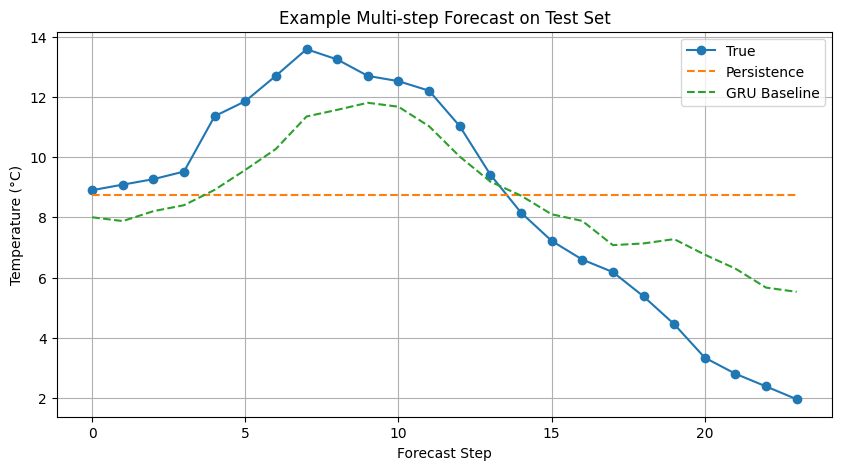

In [45]:
sample_idx = 0

plt.figure(figsize=(10, 5))
plt.plot(y_test_inv[sample_idx], label="True", marker="o")
plt.plot(y_pred_persistence_inv[sample_idx], label="Persistence", linestyle="--")
plt.plot(y_pred_gru_inv[sample_idx], label="GRU Baseline", linestyle="--")
plt.title("Example Multi-step Forecast on Test Set")
plt.xlabel("Forecast Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

## 8. Synthetic Data Generation with TimeGAN

### 8.1 Motivation and Experimental Role

The goal of the TimeGAN component is to generate realistic synthetic multivariate weather sequences using only the training split, avoiding any form of data leakage. 

These synthetic sequences will later be used to augment the training data and assess whether data augmentation improves forecasting performance, robustness, or generalization.

To keep the setup consistent with the forecasting task, the synthetic generator is trained on multivariate sequences of length `LOOKBACK + HORIZON`, so that each generated sequence can later be split into:
- an input window of length `LOOKBACK`
- a target forecasting horizon of length `HORIZON`

The impact of synthetic augmentation will be evaluated by comparing forecasting models trained with:
1. real data only
2. real data plus synthetic data

### 8.2 TimeGAN Training Data Preparation

In [63]:
from src.gan.data_prep import make_timegan_sequences, split_synthetic_sequences

TIMEGAN_SEQ_LEN = LOOKBACK + HORIZON

timegan_train_sequences = make_timegan_sequences(X_train_scaled, TIMEGAN_SEQ_LEN)

print("TimeGAN sequence length:", TIMEGAN_SEQ_LEN)
print("TimeGAN training sequences shape:", timegan_train_sequences.shape)

TimeGAN sequence length: 144
TimeGAN training sequences shape: (48885, 144, 16)


### 8.3 TimeGAN Model and Training Procedure

In [64]:
from src.gan.config import TIMEGAN_CONFIG
from src.gan.timegan import TimeGAN

TIMEGAN_CONFIG["seq_len"] = TIMEGAN_SEQ_LEN

timegan = TimeGAN(
    seq_len=TIMEGAN_CONFIG["seq_len"],
    n_features=timegan_train_sequences.shape[2],
    hidden_dim=TIMEGAN_CONFIG["hidden_dim"],
    num_layers=TIMEGAN_CONFIG["num_layers"],
    learning_rate=TIMEGAN_CONFIG["learning_rate"],
    gamma=TIMEGAN_CONFIG["gamma"],
)

print(TIMEGAN_CONFIG)
print("TimeGAN input shape:", timegan_train_sequences.shape)

{'seq_len': 144, 'hidden_dim': 24, 'num_layers': 3, 'batch_size': 128, 'epochs': 100, 'learning_rate': 0.001, 'gamma': 1.0}
TimeGAN input shape: (48885, 144, 16)


In [65]:
timegan.summary()


=== Embedder ===


Model: "embedder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 144, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedder_gru_1 (GRU)            │ (None, 144, 24)        │         3,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedder_gru_2 (GRU)            │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedder_gru_3 (GRU)            │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedder_out (TimeDistributed)  │ (None, 144, 24)        │           600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,824 (42.28 KB)

 Trainable params: 10,824 (42.28 KB)

...

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 144, 24)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_gru_1 (GRU)       │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_gru_2 (GRU)       │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_gru_3 (GRU)       │ (None, 144, 24)        │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_out               │ (None, 144, 1)         │            25 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,825 (42.29 KB)

 Trainable params: 10,825 (42.29 KB)

 Non-trainable params: 0 (0.00 B)

#### 8.3.1 Autoencoder Pretraining

In [ ]:
autoencoder_history = timegan.pretrain_autoencoder(
    sequences=timegan_train_sequences,
    epochs=TIMEGAN_CONFIG["ae_epochs"],
    batch_size=TIMEGAN_CONFIG["batch_size"],
    verbose=1,
)

Epoch 1/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 35s 77ms/step - loss: 0.2922
Epoch 2/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - loss: 0.0551
Epoch 3/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - loss: 0.0319
Epoch 4/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - loss: 0.0220
Epoch 5/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - loss: 0.0160
Epoch 6/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - loss: 0.0130
Epoch 7/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 29s 77ms/step - loss: 0.0109
Epoch 8/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - loss: 0.0092
Epoch 9/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - loss: 0.0081
Epoch 10/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - loss: 0.0072
Epoch 11/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - loss: 0.0064
Epoch 12/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - loss: 0.0059
Epoch 13/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - loss: 0.0053
Epoch 14/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 27s 71ms/step - loss: 0.0049
Epoch 15/20
382/382 ━━━━━━━━━

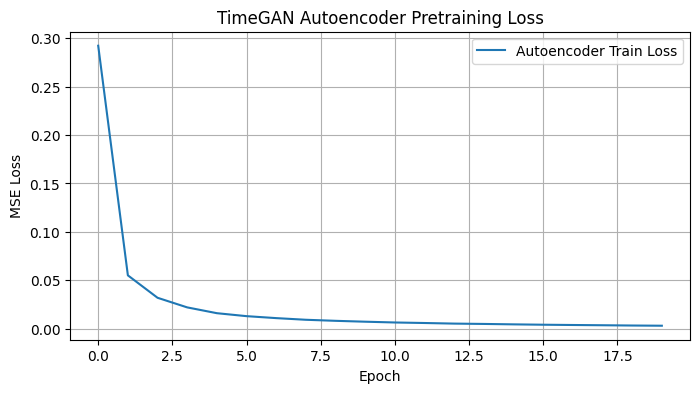

In [67]:
plt.figure(figsize=(8, 4))
plt.plot(autoencoder_history.history["loss"], label="Autoencoder Train Loss")
plt.title("TimeGAN Autoencoder Pretraining Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()

#### 8.3.2 Supervisor Pretraining

In [68]:
supervisor_history = timegan.pretrain_supervisor(
    sequences=timegan_train_sequences,
    epochs=TIMEGAN_CONFIG["sup_epochs"],
    batch_size=TIMEGAN_CONFIG["batch_size"],
    verbose=1,
)

Epoch 1/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - loss: 0.0389
Epoch 2/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - loss: 0.0107
Epoch 3/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0087
Epoch 4/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 0.0079
Epoch 5/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0075
Epoch 6/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 0.0072
Epoch 7/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0070
Epoch 8/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 0.0069
Epoch 9/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - loss: 0.0068
Epoch 10/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - loss: 0.0067
Epoch 11/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0067
Epoch 12/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - loss: 0.0067
Epoch 13/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0067
Epoch 14/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 0.0066
Epoch 15/20
382/382 ━━━━━━━━━

#### 8.3.3 Pretraining Loss Curves

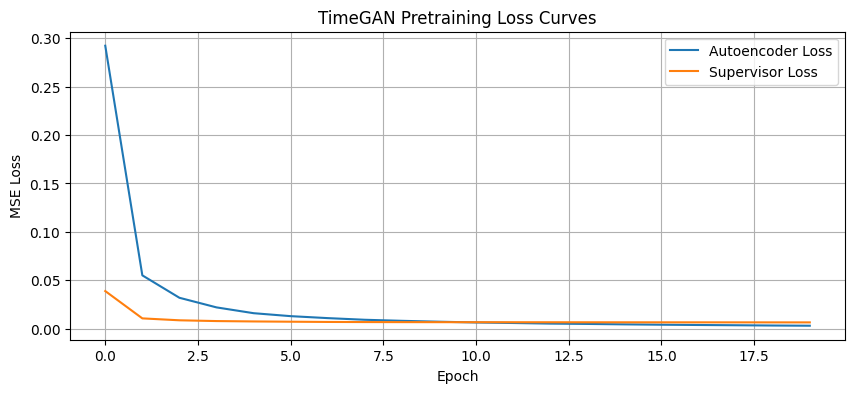

In [69]:
plt.figure(figsize=(10, 4))
plt.plot(autoencoder_history.history["loss"], label="Autoencoder Loss")
plt.plot(supervisor_history.history["loss"], label="Supervisor Loss")
plt.title("TimeGAN Pretraining Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()

#### 8.3.4 Adversarial Training 

In [70]:
adversarial_history = timegan.fit(
    sequences=timegan_train_sequences,
    epochs=TIMEGAN_CONFIG["adv_epochs"],
    batch_size=TIMEGAN_CONFIG["batch_size"],
    verbose=1,
)

KeyError: 'adv_epochs'

#### 8.3.5 Adversarial Training Loss Curves

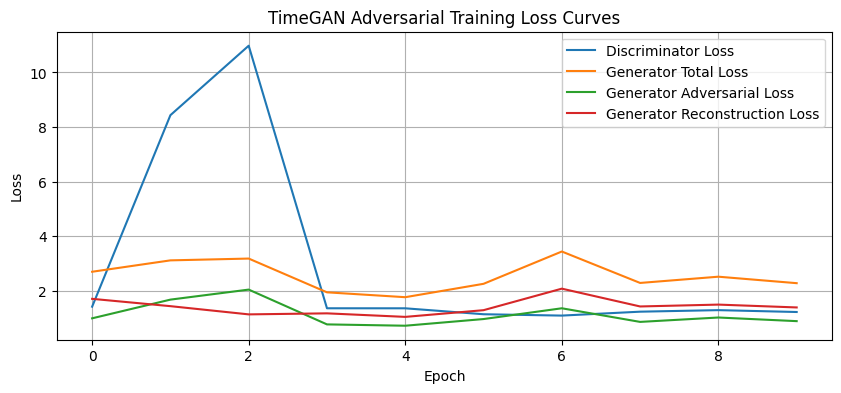

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(adversarial_history["d_loss"], label="Discriminator Loss")
plt.plot(adversarial_history["g_loss"], label="Generator Total Loss")
plt.plot(adversarial_history["g_loss_u"], label="Generator Adversarial Loss")
plt.plot(adversarial_history["g_loss_s"], label="Generator Supervised Loss")
plt.plot(adversarial_history["g_loss_v"], label="Generator Reconstruction Loss")
plt.title("TimeGAN Adversarial Training Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

### 8.4 Synthetic Sequence Quality Assessment

#### 8.4.1 Autoencoder Reconstruction Check

In [55]:
reconstructed_sequences = timegan.autoencoder.predict(
    timegan_train_sequences[:256],
    verbose=0
)

reconstruction_mse = np.mean((timegan_train_sequences[:256] - reconstructed_sequences) ** 2)

print("Reconstructed batch shape:", reconstructed_sequences.shape)
print("Reconstruction MSE on sample batch:", reconstruction_mse)

Reconstructed batch shape: (256, 144, 16)
Reconstruction MSE on sample batch: 0.0012038461465653074


#### 8.4.2 Real vs Reconstructed Sequence

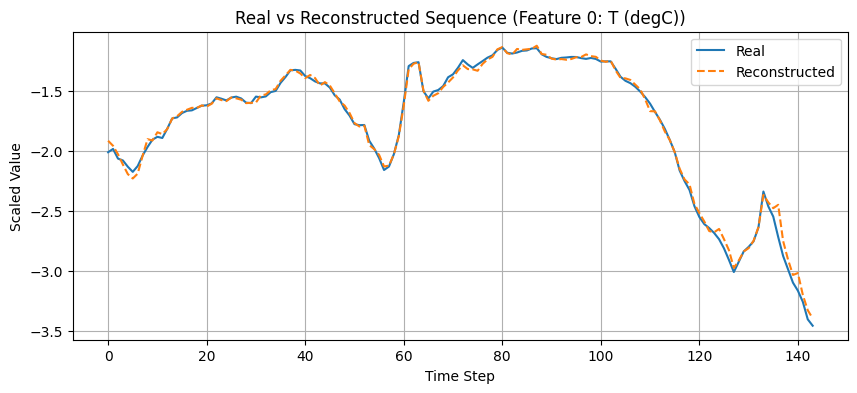

In [56]:
sample_idx = 0
feature_idx = 0  # T (degC)

plt.figure(figsize=(10, 4))
plt.plot(timegan_train_sequences[sample_idx, :, feature_idx], label="Real")
plt.plot(reconstructed_sequences[sample_idx, :, feature_idx], label="Reconstructed", linestyle="--")
plt.title("Real vs Reconstructed Sequence (Feature 0: T (degC))")
plt.xlabel("Time Step")
plt.ylabel("Scaled Value")
plt.grid(True)
plt.legend()
plt.show()

#### 8.4.3 Synthetic Sequence Preview

In [57]:
synthetic_sequences_preview = timegan.generate(8)

print("Synthetic preview shape:", synthetic_sequences_preview.shape)
print("Synthetic preview min:", synthetic_sequences_preview.min())
print("Synthetic preview max:", synthetic_sequences_preview.max())

Synthetic preview shape: (8, 144, 16)
Synthetic preview min: -1.3279158
Synthetic preview max: 1.3821212


#### 8.4.4 Real vs Synthetic Sequence

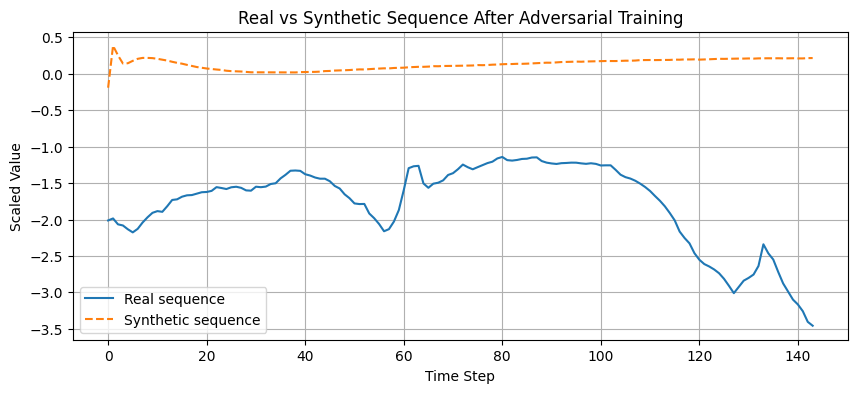

In [58]:
sample_idx = 0
feature_idx = 0  # T (degC)

plt.figure(figsize=(10, 4))
plt.plot(timegan_train_sequences[sample_idx, :, feature_idx], label="Real sequence")
plt.plot(synthetic_sequences_preview[sample_idx, :, feature_idx], label="Synthetic sequence", linestyle="--")
plt.title("Real vs Synthetic Sequence After Adversarial Training")
plt.xlabel("Time Step")
plt.ylabel("Scaled Value")
plt.grid(True)
plt.legend()
plt.show()

### 8.5 Augmented Training Set Construction

### 8.6 Forecasting Comparison With and Without Synthetic Data

## 9. Evolutionary Optimization of the Forecasting Pipeline

## 10. Retraining and Final Model Selection

## 11. Explainable AI

### 11.1 Global Explainability

### 11.2 Local Explainability

## 12. Efficiency, Latency and Resource Analysis

## 13. Comparative Discussion

## 14. Conclusion